# Example: Capital Allocation with Risky and Risk-Free Assets

In this example, we compute the maximum Sharpe ratio (tangent) portfolio for a user-chosen ticker subset, construct the Capital Allocation Line (CAL) from the risk-free rate through the tangent portfolio, and forward-simulate a blended allocation of risky and risk-free assets across synthetic futures generated by the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction.

> __Learning Objectives:__
>
> * __Tangent Portfolio:__ Compute the maximum Sharpe ratio portfolio using second-order cone programming and interpret its composition relative to the minimum-variance allocation. The tangent portfolio maximizes the risk-adjusted growth rate per unit of volatility.
> * __Capital Allocation Line:__ Construct the CAL from the risk-free rate and the tangent portfolio and explain why it dominates the risky-only efficient frontier. The CAL provides the best achievable risk-return trade-off when a risk-free asset is available.
> * __Forward Simulation:__ Evaluate synthetic out-of-sample performance of a CAL-blended portfolio against risk-free and market benchmarks. Comparing the blended allocation to passive alternatives reveals how the Sharpe advantage translates into terminal wealth.

## Setup, Data, and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

___
## Task 1: Compute the Efficient Frontier and Tangent Portfolio
We pick a small ticker subset, load the SIM calibration, assemble the SIM covariance matrix, trace the risky-only efficient frontier, and solve for the maximum Sharpe ratio (tangent) portfolio via SOCP.

> __What are we going to do?__
>
> Configure the universe of tickers and the risk-free rate, load the calibrated SIM parameters from [the `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration), build the covariance matrix and expected growth-rate vector, sweep the efficient frontier via quadratic programming, and compute the tangent portfolio via [the `solve_max_sharpe(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_max_sharpe).

In [2]:
# --- Portfolio universe ---
# Ten well-known tickers spanning sectors and betas (change this to explore
# different universes; every ticker must exist in MySIMCalibration()["tickers"]).
my_tickers = ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"];
N = length(my_tickers);

# --- Parameters ---
B₀       = 10_000.0;       # initial wealth (dollars)
r_f      = 0.045;          # 1-year risk-free rate (continuous compounding, 1/year)
n_paths  = 500;            # forward Monte Carlo paths
n_steps  = 252;            # trading days in the forward horizon
Δt       = 1.0 / 252.0;    # time step (years per trading day)

We load the cached SIM calibration and extract the parameters for the user-chosen tickers.

> __SIM Calibration:__
>
> [The `MySIMCalibration()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySIMCalibration) returns a `Dict` with $\alpha$, $\beta$, $\sigma_{\varepsilon}$, and $R^2$ for every ticker in the S&P 500 calibration universe, fitted from 2014–2024 VWAP data by regressing each ticker's annualized growth rate on SPY. All quantities are in **annualized growth-rate units** (1/year).

In [3]:
sim_estimates, σ_m = let

    # --- Step 1: Load the cached calibration and build a fast lookup ---
    calib = MySIMCalibration();
    calib_lookup = Dict{String, NamedTuple{(:a, :β, :σ_ε, :r²), NTuple{4,Float64}}}();
    for (i, t) ∈ enumerate(calib["tickers"])
        calib_lookup[t] = (a = calib["alpha"][i], β = calib["beta"][i],
                           σ_ε = calib["sigma_eps"][i], r² = calib["r_squared"][i]);
    end

    # --- Step 2: Validate that every user ticker is present ---
    missing_tickers = [t for t ∈ my_tickers if !haskey(calib_lookup, t)];
    @assert isempty(missing_tickers) "Tickers not in calibration: $(missing_tickers)"

    # --- Step 3: Build the MySIMParameterEstimate vector ---
    estimates = MySIMParameterEstimate[];
    for t ∈ my_tickers
        c = calib_lookup[t];
        est = build(MySIMParameterEstimate,
            (ticker = t, α = c.a, β = c.β, σ_ε = c.σ_ε, r² = c.r²));
        push!(estimates, est);
    end

    # --- Step 4: Extract market volatility ---
    σm = Float64(calib["sigma_market"]);

    println("Loaded SIM parameters for $(length(estimates)) tickers (from $(calib["window_start"]) to $(calib["window_end"]))");
    println("σ_market = $(round(σm, digits=4)) (annualized growth-rate std)");

    (estimates, σm)
end;

Loaded SIM parameters for 10 tickers (from 2014-01-03T05:00:00 to 2024-12-31T05:00:00)
σ_market = 2.145 (annualized growth-rate std)


The SIM expected growth-rate vector is $\mu_i = \alpha_i + \beta_i \cdot E[g_m]$ where $E[g_m]$ is pulled from [the `MySyntheticTrainingDataSet()` loader](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.MySyntheticTrainingDataSet). We assemble `μ_vec::Vector{Float64}` and `Σ::Matrix{Float64}` (both annualized, 1/year).

In [4]:
E_gm, μ_vec, Σ = let
    # --- Step 1: Expected market growth rate from the synthetic training dataset ---
    ds = MySyntheticTrainingDataSet();
    Egm = mean(ds["market_returns"]);      # 1/year

    # --- Step 2: SIM expected growth rate per ticker: μ_i = α_i + β_i · E[g_m] ---
    μ = [est.α + est.β * Egm for est ∈ sim_estimates];

    # --- Step 3: SIM covariance matrix ---
    Σ = build_sim_covariance(sim_estimates, σ_m);

    println("E[g_m] (annualized market growth rate): $(round(Egm*100, digits=2))%/yr");
    println("μ range across user tickers: [$(round(minimum(μ)*100, digits=2)), $(round(maximum(μ)*100, digits=2))]%/yr");
    println("Σ condition number: $(round(cond(Σ), digits=1))");

    (Egm, μ, Σ)
end;

E[g_m] (annualized market growth rate): 7.93%/yr
μ range across user tickers: [-1.87, 48.55]%/yr
Σ condition number: 20.2


We sweep the target return to trace the risky-only efficient frontier, solve the maximum Sharpe ratio portfolio via SOCP, and store both results.

> __Tangent Portfolio:__
>
> The tangent portfolio maximizes the Sharpe ratio $\text{SR} = (E[g_p] - r_f) / \sigma_p$ subject to long-only constraints. For the formal definition, see [the Capital Allocation Line and Tangent Portfolio section of the lecture](eCornell-AI-Finance-S1-Lecture-StressTestingMinVariancePortfolios-May-2026.ipynb). [The `solve_max_sharpe(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.solve_max_sharpe) solves this via second-order cone programming (SOCP) using the Clarabel optimizer.

In [5]:
minvar_result, frontier_risk, frontier_return, sharpe_result = let

    # --- Step 1: Long-only bounds ---
    bounds = hcat(zeros(N), ones(N));

    # --- Step 2: Solve the minimum-variance QP at a moderate target return ---
    R_target = 0.10;
    problem = build(MyPortfolioAllocationProblem;
        μ = μ_vec, Σ = Σ, bounds = bounds, R = R_target);
    mv = solve_minvariance(problem);

    # --- Step 3: Sweep the target return to trace the efficient frontier ---
    R_sweep = range(0.0, stop = maximum(μ_vec) * 0.95, length = 100) |> collect;
    f_risk = Float64[];
    f_return = Float64[];
    for R ∈ R_sweep
        p = build(MyPortfolioAllocationProblem; μ = μ_vec, Σ = Σ, bounds = bounds, R = R);
        sol = solve_minvariance(p);
        push!(f_risk, sqrt(sol.variance));
        push!(f_return, sol.expected_return);
    end

    # --- Step 4: Solve the max-Sharpe (tangent) portfolio ---
    α_vec = [est.α for est ∈ sim_estimates];
    β_vec = [est.β for est ∈ sim_estimates];
    sharpe_problem = build(MySharpeRatioPortfolioChoiceProblem, (
        Σ = Σ, risk_free_rate = r_f, α = α_vec, β = β_vec,
        gₘ = E_gm, bounds = bounds));
    sr = solve_max_sharpe(sharpe_problem);

    mv_vol = sqrt(mv.variance);
    tang_vol = sr["volatility"];
    tang_ret = sr["expected_return"];
    sr_ann = sr["sharpe_ratio"];
    sr_trad = sr_ann * sqrt(1/Δt);  # traditional (per-Δt) Sharpe = annualized SR × √(1/Δt)

    println("Min-var portfolio: E[g] = $(round(mv.expected_return*100, digits=2))%/yr, σ = $(round(mv_vol*100, digits=2))%/yr");
    println("Tangent portfolio: E[g] = $(round(tang_ret*100, digits=2))%/yr, σ = $(round(tang_vol*100, digits=2))%/yr");
    println("Sharpe ratio (annualized units): $(round(sr_ann, digits=4))");
    println("Sharpe ratio (traditional, per-Δt):  $(round(sr_trad, digits=4))");

    (mv, f_risk, f_return, sr)
end;


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Min-var portfolio: E[g] = 10.0%/yr, σ = 198.01%/yr
Tangent portfolio: E[g] = 48.55%/yr, σ = 616.99%/yr
Sharpe ratio (annualized units): 0.0714
Sharpe ratio (traditional, per-Δt):  1.1334


The tangent portfolio weights and the Sharpe ratio tell us which assets contribute most to risk-adjusted performance.

> __Sharpe Ratio Units:__
>
> Because our SIM parameters are in annualized growth-rate units (1/year), the Sharpe ratio from the SOCP is also in annualized units: $\text{SR}_{\text{ann}} = (E[g_p] - r_f) / \sigma_p$ where both the numerator and denominator are in 1/year. The **traditional** (per-timestep) Sharpe ratio used in most finance textbooks scales by $\sqrt{1/\Delta t} = \sqrt{252}$: $\text{SR}_{\text{trad}} = \text{SR}_{\text{ann}} \times \sqrt{252}$. We report both below.

In [6]:
tangent_weights = let
    w = sharpe_result["weights"];

    df = DataFrame(
        "Ticker"     => my_tickers,
        "Weight (%)" => round.(w .* 100, digits=2),
        "β"          => round.([est.β for est ∈ sim_estimates], digits=3),
        "α (%/yr)"   => round.([est.α for est ∈ sim_estimates] .* 100, digits=2),
    );

    println("Tangent portfolio allocation (Sharpe ratio = $(round(sharpe_result["sharpe_ratio"], digits=4))):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    w
end;

Tangent portfolio allocation (Sharpe ratio = 0.0714):
 -------- ------------ --------- ----------
  Ticker   Weight (%)         β   α (%/yr) 
  String      Float64   Float64    Float64 
 -------- ------------ --------- ----------
    AAPL          0.0     1.195      10.61
    MSFT          0.0     1.152       9.99
    NVDA        100.0     1.749      34.68
     JNJ          0.0      0.54      -1.62
     JPM          0.0     1.204       0.05
      PG          0.0     0.491       1.47
     XOM         -0.0     0.951      -9.41
      BA         -0.0     1.527      -13.9
      GS          0.0      1.31      -3.26
     AMD          0.0     1.739      12.75
 -------- ------------ --------- ----------


___
## Task 2: Construct and Visualize the Capital Allocation Line
We construct the CAL as a straight line from the risk-free rate through the tangent portfolio and overlay it on the efficient frontier to show that mixing risky and risk-free assets dominates the risky-only frontier at every risk level.

> __Capital Allocation Line (CAL):__
>
> The CAL is the set of portfolios formed by mixing the tangent portfolio with the risk-free asset in proportion $\theta \in [0, \infty)$. Its equation is $E[g_p] = r_f + \text{SR}_{\text{tangent}} \cdot \sigma_p$ where $\text{SR}_{\text{tangent}}$ is the maximum Sharpe ratio. For the formal derivation, see [the Capital Allocation Line and Tangent Portfolio section of the lecture](eCornell-AI-Finance-S1-Lecture-StressTestingMinVariancePortfolios-May-2026.ipynb). Points with $\theta < 1$ lend at the risk-free rate; points with $\theta > 1$ borrow at the risk-free rate.

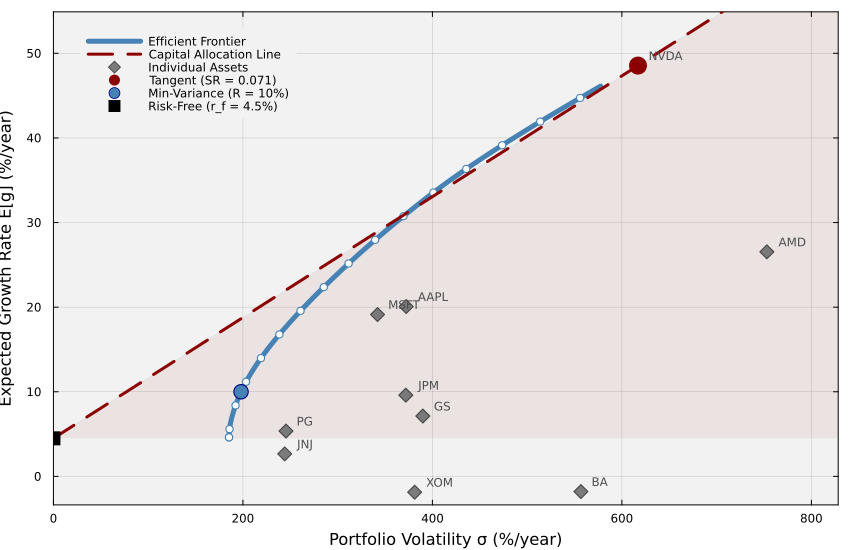

In [7]:
let
    # --- Extract coordinates ---
    tang_ret = sharpe_result["expected_return"];
    tang_vol = sharpe_result["volatility"];
    sr       = sharpe_result["sharpe_ratio"];
    mv_ret   = minvar_result.expected_return;
    mv_vol   = sqrt(minvar_result.variance);

    # --- Individual asset risk/return ---
    σ_assets = [sqrt(Σ[i,i]) for i ∈ 1:N];

    # --- Convert to percentage ---
    fr_pct  = frontier_risk .* 100;
    fμ_pct  = frontier_return .* 100;
    σa_pct  = σ_assets .* 100;
    μa_pct  = μ_vec .* 100;

    # --- Axis limits: driven by data, not one outlier asset ---
    x_hi = max(maximum(σa_pct), maximum(fr_pct)) * 1.10;
    y_lo = min(0.0, minimum(fμ_pct), minimum(μa_pct)) - 1.5;
    y_hi = max(maximum(fμ_pct), maximum(μa_pct)) * 1.10 + 1.5;

    # --- CAL extends to right edge of plot ---
    cal_x = range(0, stop = x_hi, length = 100) |> collect;
    cal_y = r_f * 100 .+ sr .* cal_x;

    # --- Annotation offsets scale with axis range ---
    dx = x_hi * 0.015;
    dy = (y_hi - y_lo) * 0.02;

    # --- Build the plot ---
    p = plot(size = (850, 550), fontsize = 14,
        xlabel = "Portfolio Volatility σ (%/year)",
        ylabel = "Expected Growth Rate E[g] (%/year)",
        xlim = (0, x_hi), ylim = (y_lo, y_hi),
        legend = :topleft);

    # --- Shade the CAL region ---
    plot!(p, cal_x, cal_y, fillrange = r_f * 100, fillalpha = 0.07,
        fillcolor = :darkred, lw = 0, label = "");

    # --- Efficient frontier ---
    skip = max(1, length(fr_pct) ÷ 15);
    plot!(p, fr_pct, fμ_pct, lw = 5, color = :steelblue,
        label = "Efficient Frontier");
    scatter!(p, fr_pct[1:skip:end], fμ_pct[1:skip:end],
        ms = 4, color = :white, msc = :steelblue, label = "");

    # --- CAL ---
    plot!(p, cal_x, cal_y, lw = 3, ls = :dash, color = :darkred,
        label = "Capital Allocation Line");

    # --- Individual assets ---
    scatter!(p, σa_pct, μa_pct, ms = 7, color = :gray40, msc = :gray20,
        marker = :diamond, alpha = 0.85, label = "Individual Assets");
    for i ∈ 1:N
        annotate!(p, σa_pct[i] + dx, μa_pct[i] + dy,
            text(my_tickers[i], 8, :left, :gray30));
    end

    # --- Key points ---
    scatter!(p, [tang_vol * 100], [tang_ret * 100],
        marker = :circle, ms = 10, color = :darkred, msc = :darkred,
        label = "Tangent (SR = $(round(sr, digits=3)))");
    scatter!(p, [mv_vol * 100], [mv_ret * 100],
        marker = :circle, ms = 8, color = :steelblue, msc = :navy,
        label = "Min-Variance (R = 10%)");
    scatter!(p, [0.0], [r_f * 100],
        marker = :square, ms = 7, color = :black, msc = :black,
        label = "Risk-Free (r_f = $(round(r_f*100, digits=1))%)");

    plot!(p, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
    display(p)
end

Every point on the CAL dominates the corresponding point on the risky-only frontier at the same risk level. An investor who can lend or borrow at $r_f$ should always hold the tangent portfolio as their risky allocation and adjust total risk by varying $\theta$ (the fraction in risky assets).

The table below shows how the blended portfolio's expected growth rate and volatility change as $\theta$ varies from 0 (pure risk-free) to 1 (pure tangent) and beyond.

In [8]:
let
    tang_ret = sharpe_result["expected_return"];
    tang_vol = sharpe_result["volatility"];
    sr       = sharpe_result["sharpe_ratio"];
    mv_ret   = minvar_result.expected_return;
    mv_vol   = sqrt(minvar_result.variance);
    mv_sr    = (mv_ret - r_f) / mv_vol;
    mv_sr_trad = mv_sr * sqrt(1/Δt);

    # --- Blended portfolios along the CAL ---
    θ_values = [0.0, 0.25, 0.50, 0.75, 0.90, 1.0];
    df = DataFrame(
        "θ (risky %)"   => round.(θ_values .* 100, digits=0),
        "E[g] (%/yr)"   => round.((r_f .+ θ_values .* (tang_ret - r_f)) .* 100, digits=2),
        "σ (%/yr)"      => round.((θ_values .* tang_vol) .* 100, digits=2),
        "SR (ann)"      => fill(round(sr, digits=4), length(θ_values)),
        "SR (trad)"     => fill(round(sr * sqrt(1/Δt), digits=2), length(θ_values)),
    );

    println("Capital Allocation Line: risk-return choices by θ");
    println("(Min-var Sharpe: ann = $(round(mv_sr, digits=4)), trad = $(round(mv_sr_trad, digits=2)))");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

Capital Allocation Line: risk-return choices by θ
(Min-var Sharpe: ann = 0.0278, trad = 0.44)
 ------------- ------------- ---------- ---------- -----------
  θ (risky %)   E[g] (%/yr)   σ (%/yr)   SR (ann)   SR (trad) 
      Float64       Float64    Float64    Float64     Float64 
 ------------- ------------- ---------- ---------- -----------
          0.0           4.5        0.0     0.0714        1.13
         25.0         15.51     154.25     0.0714        1.13
         50.0         26.53     308.49     0.0714        1.13
         75.0         37.54     462.74     0.0714        1.13
         90.0         44.15     555.29     0.0714        1.13
        100.0         48.55     616.99     0.0714        1.13
 ------------- ------------- ---------- ---------- -----------


___
## Task 3: Forward-Simulate the Tangent Portfolio Along the CAL
We pick a blending fraction $\theta$, resolve starting prices, generate synthetic forward paths via the hybrid JumpHMM construction, and compare the blended tangent portfolio against a pure risk-free baseline and a buy-the-market (SPY) benchmark.

> __What are we going to do?__
>
> Allocate $\theta \cdot B_0$ to the tangent portfolio and $(1-\theta) \cdot B_0$ to the risk-free asset. Generate 500 synthetic forward paths with [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario), hold buy-and-hold for one year, and compare terminal wealth against the continuously compounded risk-free baseline and the market portfolio.

In [9]:
θ = 0.90; # fraction of wealth in the tangent (risky) portfolio

We resolve starting prices for each ticker from the cached price snapshot and generate the hybrid forward scenario.

In [10]:
start_prices = let
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    sp = Dict{String, Float64}();
    for t ∈ my_tickers
        @assert haskey(snap_lookup, t) "Ticker $(t) not in MyCurrentPrices() snapshot"
        sp[t] = snap_lookup[t];
    end

    println("Starting prices (from $(snap["source_label"])): ");
    df = DataFrame(
        "Ticker"     => my_tickers,
        "Price (\$)" => [round(sp[t], digits=2) for t ∈ my_tickers],
    );
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    sp
end;

Starting prices (from polygon-ohlc-testing-dataset): 
 -------- -----------
  Ticker   Price ($) 
  String     Float64 
 -------- -----------
    AAPL      271.86
    MSFT      483.62
    NVDA       186.5
     JNJ      206.95
     JPM      322.22
      PG      143.31
     XOM      120.34
      BA      217.12
      GS       879.0
     AMD      214.16
 -------- -----------


In [11]:
scenario = let
    # --- Step 1: Load the surrogate models (cached on disk) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = MySIMCalibration();

    # --- Step 2: Generate the hybrid forward scenario ---
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Hybrid-SIM ($(n_paths) paths, $(n_steps) days)",
        seed    = 2026);

    println("Generated scenario: $(scen.n_paths) paths × $(scen.n_steps) days × $(N) tickers");
    scen
end;

Generated scenario: 500 paths × 252 days × 10 tickers


We compute buy-and-hold wealth trajectories for three strategies: the $\theta$-blended tangent portfolio, the pure risk-free asset, and the market (SPY) benchmark.

In [12]:
result_tangent, result_mkt = let

    # --- Step 1: Buy-and-hold the tangent portfolio (risky portion only) ---
    r_tang = backtest_buyhold(scenario, my_tickers;
        B₀      = B₀ * θ,
        offset  = 1,
        weights = tangent_weights);

    # --- Step 2: Buy-and-hold the market (SPY) ---
    r_mkt = backtest_buyhold_market(scenario;
        B₀ = B₀);

    rf_terminal = B₀ * exp(r_f * n_steps * Δt);
    θ_rf_terminal = (1 - θ) * rf_terminal;
    blended_median = median(r_tang.final_wealth) + θ_rf_terminal;

    println("Blended tangent (θ=$(θ)): median final = \$$(round(blended_median, digits=2))");
    println("Market (SPY): median final = \$$(round(median(r_mkt.final_wealth), digits=2))");
    println("Risk-free only: final = \$$(round(rf_terminal, digits=2))");

    (r_tang, r_mkt)
end;

Blended tangent (θ=0.9): median final = $25427.72
Market (SPY): median final = $11167.44
Risk-free only: final = $10460.28


The plot below shows a random sample of wealth trajectories for the blended tangent portfolio, with the median, the risk-free baseline, and the SPY benchmark overlaid.

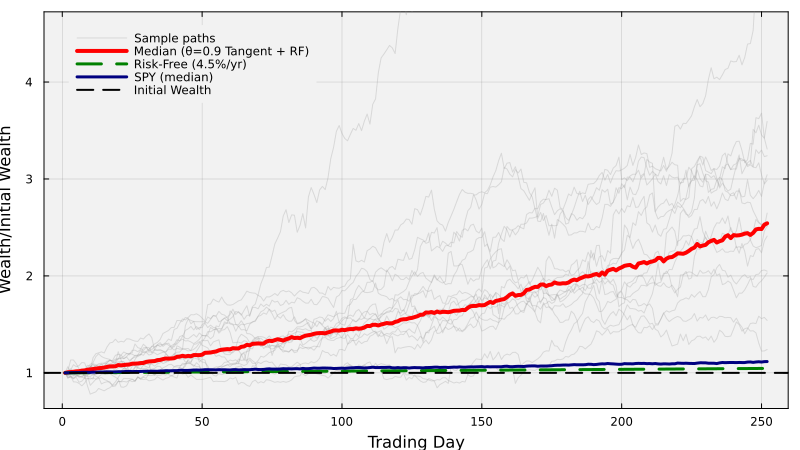

In [13]:
let
    Random.seed!(2027);
    sample_idx = rand(1:n_paths, 15);
    K = length(my_tickers);

    p = plot(xlabel = "Trading Day", ylabel = "Wealth/Initial Wealth",
        legend = :topleft, size = (800, 450), fontsize = 14);

    # --- Median blended wealth across all paths (compute first for ylims) ---
    all_blended = zeros(n_steps, n_paths);
    for pidx ∈ 1:n_paths
        shares = [(θ * B₀ * tangent_weights[k]) / scenario.price_paths[pidx, 1, k] for k in 1:K];
        for t ∈ 1:n_steps
            risky = sum(shares[k] * scenario.price_paths[pidx, t, k] for k in 1:K);
            all_blended[t, pidx] = (1/B₀) * (risky + (1 - θ) * B₀ * exp(r_f * t * Δt));
        end
    end

    # --- y-axis limits from the bulk of the distribution (clip outliers) ---
    y_lo = quantile(vec(all_blended), 0.02);
    y_hi = quantile(vec(all_blended), 0.98);
    y_pad = 0.05 * (y_hi - y_lo);

    # --- Sample paths ---
    for (j, pidx) ∈ enumerate(sample_idx)
        shares = [(θ * B₀ * tangent_weights[k]) / scenario.price_paths[pidx, 1, k] for k in 1:K];
        risky_wealth = [sum(shares[k] * scenario.price_paths[pidx, t, k] for k in 1:K) for t ∈ 1:n_steps];
        rf_part = [(1 - θ) * B₀ * exp(r_f * t * Δt) for t ∈ 1:n_steps];
        blended = (1/B₀) .* (risky_wealth .+ rf_part);
        plot!(p, 1:n_steps, blended, lw = 1, alpha = 0.3, color = :gray60, label = (j == 1 ? "Sample paths" : ""));
    end

    # --- Median ---
    median_blended = [median(all_blended[t, :]) for t ∈ 1:n_steps];
    plot!(p, 1:n_steps, median_blended, lw = 4, color = :red, label = "Median (θ=$(θ) Tangent + RF)");

    # --- Risk-free baseline ---
    rf_line = [exp(r_f * t * Δt) for t ∈ 1:n_steps];
    plot!(p, 1:n_steps, rf_line, lw = 3, ls = :dash, color = :green, label = "Risk-Free ($(round(r_f*100, digits=1))%/yr)");

    # --- SPY median ---
    spy_price0 = median([scenario.market_paths[pidx, 1] for pidx in 1:n_paths]);
    spy_wealth = [median([scenario.market_paths[pidx, t] for pidx in 1:n_paths]) / spy_price0 for t ∈ 1:n_steps];
    plot!(p, 1:n_steps, spy_wealth, lw = 3, color = :navy, label = "SPY (median)");

    hline!(p, [1.0], lw = 2, ls = :dash, color = :black, label = "Initial Wealth");
    plot!(p, ylims = (y_lo - y_pad, y_hi + y_pad),
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
    display(p)
end

Finally we summarize the forward simulation results in a scorecard table and save the tangent allocation to disk.

In [14]:
let
    T_years  = n_steps / 252;
    rf_terminal = B₀ * exp(r_f * T_years);
    θ_rf_terminal = (1 - θ) * rf_terminal;

    # Blended final wealth = risky part + risk-free part
    blended_final = result_tangent.final_wealth .+ θ_rf_terminal;

    function summary_row(name, final_wealth)
        med_w = median(final_wealth);
        var5  = quantile(final_wealth, 0.05);
        vol   = std(final_wealth);
        sr_val = vol > 0 ? (med_w - B₀) / vol : 0.0;
        return (Portfolio = name,
                Median_W = round(med_w, digits=0),
                VaR_5 = round(var5, digits=0),
                Sharpe = round(sr_val, digits=3));
    end

    rows = [
        summary_row("Tangent (θ=$(θ))", blended_final),
        summary_row("Market (SPY)",     result_mkt.final_wealth),
        (Portfolio = "Risk-Free ($(round(r_f*100, digits=1))%)",
         Median_W = round(rf_terminal, digits=0),
         VaR_5 = round(rf_terminal, digits=0),
         Sharpe = "---"),
    ];
    df = DataFrame(rows);

    println("Forward simulation summary ($(n_paths) paths, $(n_steps) days, θ=$(θ)):");
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
end

Forward simulation summary (500 paths, 252 days, θ=0.9):
 ------------------ ---------- --------- --------
         Portfolio   Median_W     VaR_5   Sharpe 
            String    Float64   Float64      Any 
 ------------------ ---------- --------- --------
   Tangent (θ=0.9)    25428.0   11621.0    0.947
      Market (SPY)    11167.0    8196.0     0.59
  Risk-Free (4.5%)    10460.0   10460.0      ---
 ------------------ ---------- --------- --------


In [15]:
let
    save_path = joinpath(_PATH_TO_DATA, "tangent-allocation.jld2");
    save_results(save_path, Dict(
        "my_tickers"       => my_tickers,
        "tangent_weights"  => tangent_weights,
        "sharpe_ratio"     => sharpe_result["sharpe_ratio"],
        "expected_return"  => sharpe_result["expected_return"],
        "volatility"       => sharpe_result["volatility"],
        "r_f"              => r_f,
        "theta"            => θ,
        "sim_estimates"    => sim_estimates,
        "sigma_market"     => σ_m,
    ));
    println("Saved tangent allocation to: $(save_path)");
end

Saved tangent allocation to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/tangent-allocation.jld2


___
## Summary
This example computed the maximum Sharpe ratio (tangent) portfolio via SOCP, constructed the Capital Allocation Line from the risk-free rate through the tangent portfolio, and forward-simulated a blended allocation across synthetic futures to compare against passive benchmarks.

> __Key Takeaways:__
>
> * __The tangent portfolio maximizes risk-adjusted growth:__ By solving a second-order cone program we identify the single risky portfolio with the highest Sharpe ratio. This portfolio sits at the point where the CAL is tangent to the efficient frontier.
> * __The CAL dominates the risky-only frontier:__ Any investor who can lend or borrow at the risk-free rate achieves a better risk-return trade-off on the CAL than on the frontier alone. The blending fraction controls total risk without changing the risky allocation.
> * __Synthetic forward simulation grounds the theory in distributional outcomes:__ The hybrid JumpHMM construction generates realistic futures that preserve heavy tails and regime structure. Comparing blended wealth against SPY and the risk-free baseline shows whether the Sharpe advantage survives over a one-year horizon.

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.